In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

In [ ]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [ ]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

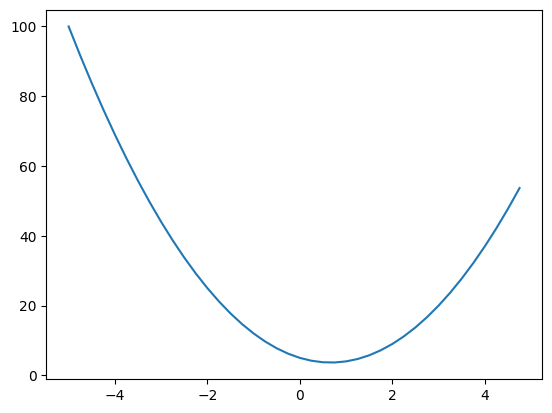

In [ ]:
plt.plot(xs, ys)

In [ ]:
h = 0.001
x = 3.0
print(f(x))
print(f(x+h))

20.0
20.014003000000002


In [ ]:
f(x+h)-f(x)

0.01400300000000243

In [ ]:
(f(x+h)-f(x))/h

14.00300000000243

In [ ]:
h = 0.00000001
(f(x+h)-f(x))/h

14.00000009255109

In [ ]:
# A more complex example
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

print(d)

4.0


In [ ]:
# inputs at which we want to calculate function d's slope with respect to individual variables
a = 2.0
b = -3.0
c = 10.0

# derivative wrt to a at points a, b and c

# original value
d1 = a*b + c

# bumped value
h = 0.0001
a = a + h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("derivative", (d2-d1)/h)


d1 4.0
d2 3.999699999999999
derivative -3.000000000010772


In [ ]:
class Value:
  def __init__(self, data, _children=(), _op=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op

# <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    return Value(self.data + other.data, (self, other), '+')

  def __mul__(self, other):
    return Value(self.data * other.data, (self, other), '*')



In [ ]:
a = Value(2.0)
a

Value(data=2.0)

In [ ]:
a = Value(2.0)
b = Value(-3.0)
a + b

Value(data=-1.0)

In [ ]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
a*b + c
# (a.__mul__(b)).__add__(c)

Value(data=4.0)

In [ ]:
d = a*b + c
d._prev, d._op

({Value(data=-6.0), Value(data=10.0)}, '+')

In [ ]:
list(d._prev)[1]._prev

set()

In [ ]:
id(0)

10757704

In [ ]:
from graphviz import Digraph

def trace(root):
  #DFS
  nodes, edges = set(), set()

  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v)) # --> set of tuples representing heirarchy from child to parent
        build(child)

  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) # LR = left to right

  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    # create a box node/record for each node

    dot.node(name=uid, label= "{data %.4f}" % (n.data, ), shape = 'record')

    if n._op:
      #if current value node resulted from some operation then create its operation node
      dot.node(name = uid + n._op, label = n._op)

      #connect the operation node to the parent node
      dot.edge(uid + n._op, uid)

  # add in all the edges between children and parent via the operation node
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
uid = str(id(5))
uid

'10757864'

In [ ]:
id('A') ## id is a unique number created for each python object (runtime dependent)

10801984

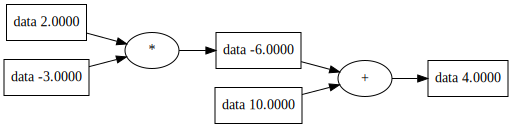

In [ ]:
draw_dot(d)

In [ ]:
# Adding labels and a grad variable
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label

# <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    return Value(self.data + other.data, (self, other), '+')

  def __mul__(self, other):
    return Value(self.data * other.data, (self, other), '*')


In [ ]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d, d.label

f = Value(-2.0, label = 'f')
L = d*f; L.label = 'L'

In [ ]:
from graphviz import Digraph

def trace(root):
  #BFS
  nodes, edges = set(), set()

  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v)) # --> set of tuples representing heirarchy from child to parent
        build(child)

  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) # LR = left to right

  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    # create a box node/record for each node

    # add label to record
    dot.node(name=uid, label= "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')

    if n._op:
      #if current value node resulted from some operation then create its operation node
      dot.node(name = uid + n._op, label = n._op)

      #connect the operation node to the parent node
      dot.edge(uid + n._op, uid)

  # add in all the edges between children and parent via the operation node
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

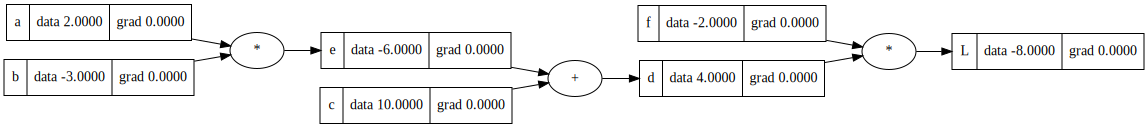

In [ ]:
draw_dot(L)

In [ ]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d, d.label

f = Value(-2.0, label = 'f')
L = d*f; L.label = 'L'


# dL / dL = 1
# dL / dd = f = -2
# dL / df = d = 4
# dL / dc = dL / dd * dd/dc = -2 * 1 = -2
# dL / de = dL / dd * dd/de = -2 * 1 = -2
# dL / db = dL / dd * dd/de * de/db = -2 * 1 * a = -2 * 1 * 2 = 4
# dL / da = dL / dd * dd/de * de/da = -2 * 1 * b = -2 * 1 * -3 = 6

a.grad = 6.0
b.grad = -4.0
c.grad = -2.0
e.grad = -2.0
d.grad = 4.0
f.grad = -2.0

In [ ]:
def verify():

  a = Value(2.0, label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  d, d.label

  f = Value(-2.0, label = 'f')
  L = d*f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  d, d.label

  f = Value(-2.0, label = 'f')
  L = d*f; L.label = 'L'
  L2 = L.data

  print((L2-L1)/h)

In [ ]:
verify()

0.0


## Applying backpropogration to a neuron

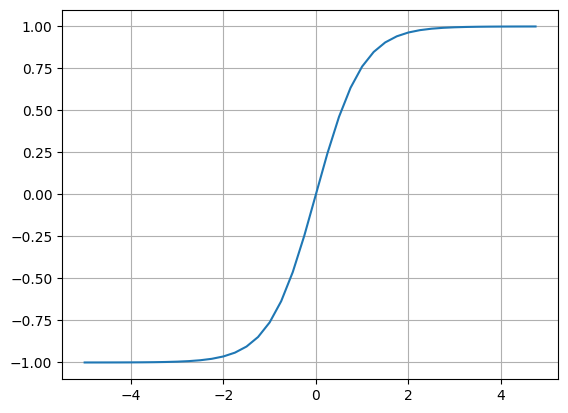

In [ ]:
# activation function to be used - tanh
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25))); plt.grid()

In [ ]:
# Adding tanh
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label

# <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    return Value(self.data + other.data, (self, other), '+')

  def __mul__(self, other):
    return Value(self.data * other.data, (self, other), '*')

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    return Value(t, (self, ), 'tanh')

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

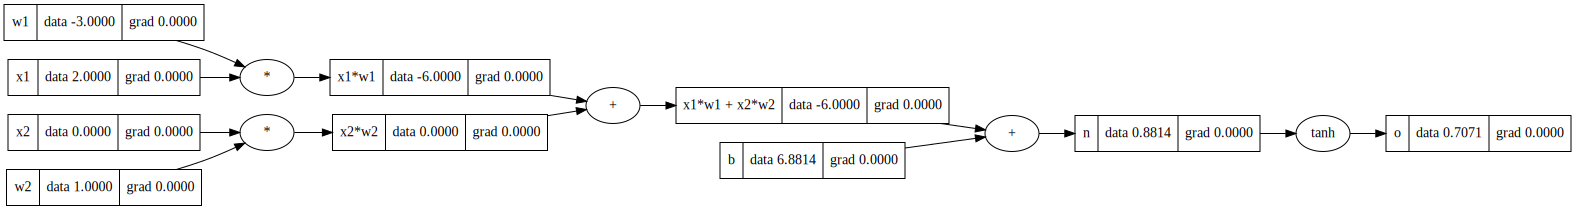

In [ ]:
draw_dot(o)

In [ ]:
o.grad = 1.0
n.grad = 1 - o.data**2 * o.grad
b.grad = n.grad
x1w1x2w2.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad



## Moving the backwards gradient update logic to respective parent nodes

In [ ]:
# Adding a variable that tracks the backward function per node, this variable is set when an operation creates said node
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._backward = lambda : None
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label

# <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):

    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

    out =  Value(t, (self, ), 'tanh')

    def _backward():
        self.grad = 1 - out.data**2
    out._backward = _backward

    return out

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

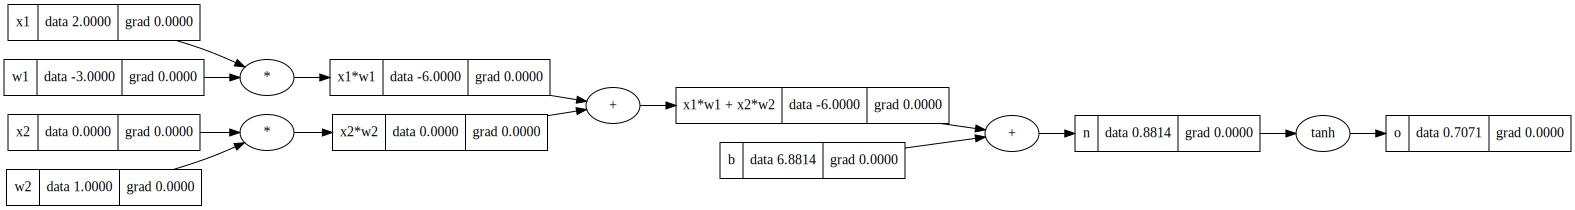

In [ ]:
draw_dot(o)

In [ ]:
# 1-o.data**2

In [ ]:
o.grad = 1.0

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
b._backward()
x1w1x2w2._backward()

In [ ]:
x1w1._backward()
x2w2._backward()

## Topological sort - so that we don't have to worry about the order in which to call _backward()

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'


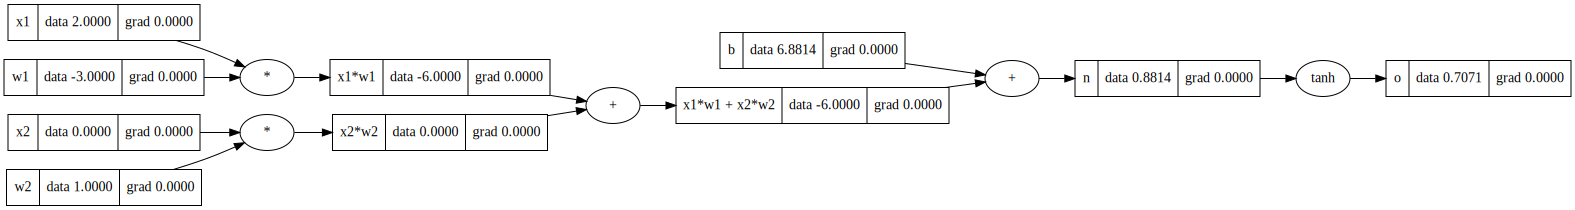

In [ ]:
draw_dot(o)

In [ ]:
o.grad = 1.0

topo = []

def build_topo(v):
  visited = set()
  if v not in visited:
    visited.add(v)
    for ele in v._prev:
      build_topo(ele)
    topo.append(v)

build_topo(o)
topo

[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [ ]:
## Testing what the purpose of maintaining a visited queue is in the previous code
topo_test = []

def build_topo(v):
  for ele in v._prev:
    build_topo(ele)
  topo_test.append(v)

build_topo(o)
topo_test

[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [ ]:
for node in reversed(topo):
  node._backward()

## Hiding it all away

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._backward = lambda : None
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label

# <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):

    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

    out =  Value(t, (self, ), 'tanh')

    def _backward():
        self.grad = 1 - out.data**2
    out._backward = _backward

    return out

  def backward(self):

    topo = []

    def build_topo(v):
      visited = set()
      if v not in visited:
        visited.add(v)
        for ele in v._prev:
          build_topo(ele)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0

    for node in reversed(topo):
      node._backward()

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

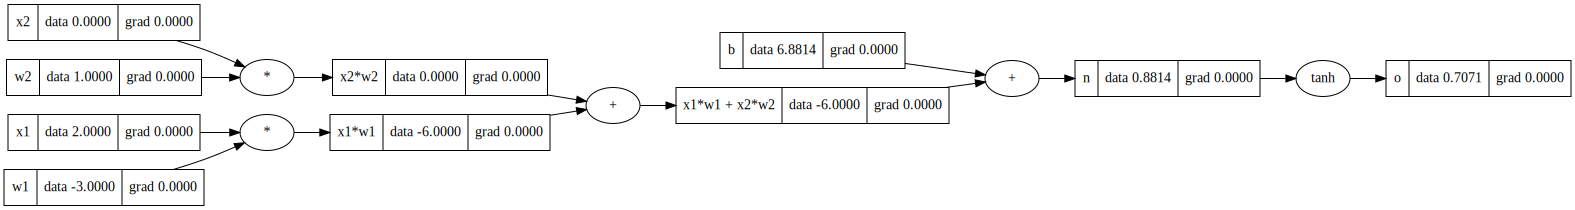

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

## Fixing the multivariate chain rule backward grad update BUG

### Solution: Accumulate gradients instead of overwriting them

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._backward = lambda : None
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other) ## handle type checking before any computation
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other) ## handle type checking before any computation
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():

      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
      # print(f"{self.label} with grad {self.grad}")

    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only support int/float powers" ## handle type checking before any computation

    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += (other*(self.data**(other-1)))*out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad = out.data * out.grad # MISTAKE - FORGOT TO ACCUMULATE OLD GRADIENT

    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

    out =  Value(t, (self, ), 'tanh')

    def _backward():
        self.grad += 1 - out.data**2 # MISTAKE - FORGOT TO MULTIPLY BY OLD GRADIENT
    out._backward = _backward

    return out

  # <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __radd__(self, other):
    return self+other

  # don't need specific backward pass instructions for these as we are using already defined primitives
  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __rmul__(self, other): # multiplies other*self from original order
    return self*other

  def __truediv__(self, other):
    return self * other**-1

  def backward(self):

    topo = []
    visited = set()

    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for ele in v._prev:
          build_topo(ele)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    # print(topo)
    for node in reversed(topo):
      node._backward()

In [ ]:
a = Value(4.0, label='a')
b = Value(2.0, label='b')
a*2

Value(data=8.0)

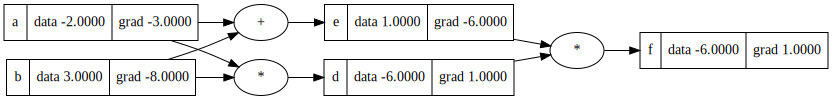

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'

f.backward()

draw_dot(f)

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

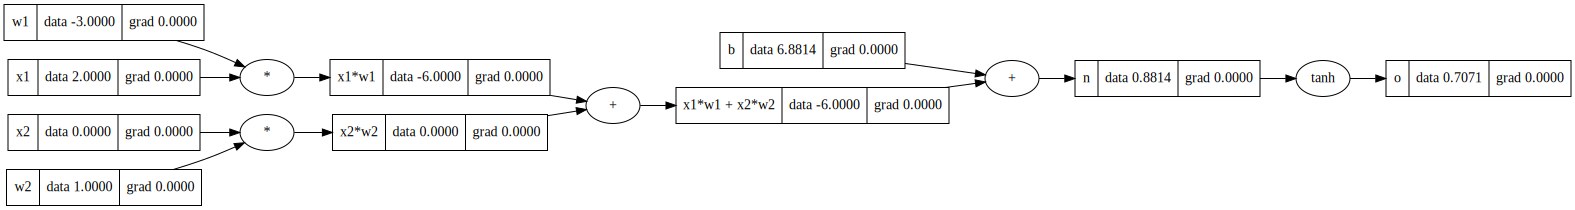

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

In [ ]:
# inputs x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights on synapses w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias term b
b = Value(6.8813735870195432, label = 'b')

# neuron computation
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp();e.label = 'e'
o = (e - 1)/(e + 1)

o.label = 'o'

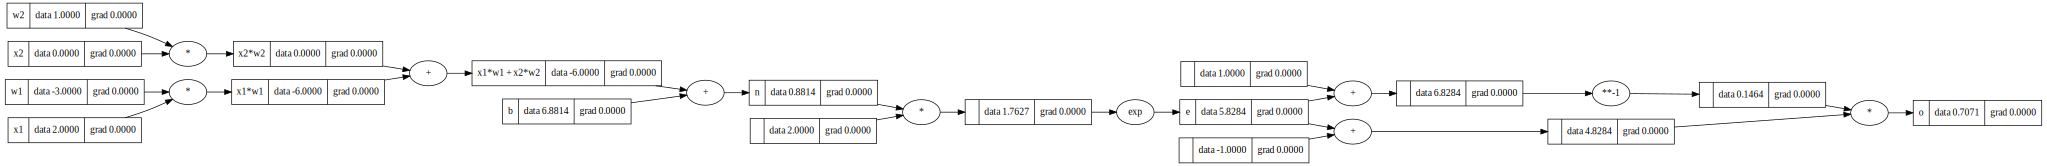

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

In [ ]:
list(e._prev)[0]._prev

{Value(data=0.8813735870195432), Value(data=2)}

In [ ]:
list(e._prev)[0]._op

'*'

In [ ]:
list(list(e._prev)[0]._prev)[0].grad

0.2203433967548858

## Pytorch Equivalent Code

In [ ]:
import torch
# inputs x1 and x2
x1 = torch.Tensor([2.0]).double()                   ;x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                   ;x2.requires_grad = True
# weights on synapses w1 and w2
w1 = torch.Tensor([-3.0]).double()                  ;w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                   ;w2.requires_grad = True
# bias term b
b = torch.Tensor([6.8813735870195432]).double()     ;b.requires_grad = True

# neuron computation
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)


In [ ]:
print(o.data.item())

0.7071066904050358


In [ ]:
o.backward()

In [ ]:
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item()) # .item() strips the data from the tensor data element
print('w2', w2.grad.item())

x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


In [ ]:
import torch
# inputs x1 and x2
x1 = torch.Tensor([2.0]).double() ## default precision is float32 in torch --> change to float64 which is the Python default
x1.dtype

torch.float64

#Making a Neuron, Layer and MLP class

In [ ]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum([wi*xi for wi, xi in zip(self.w, x)]) + self.b
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [neuron(x) for neuron in self.neurons]
    return outs[0] if len(outs)==1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) # output of one layer fed back to the next layer --> therefore update x
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=0.7436352864052901)

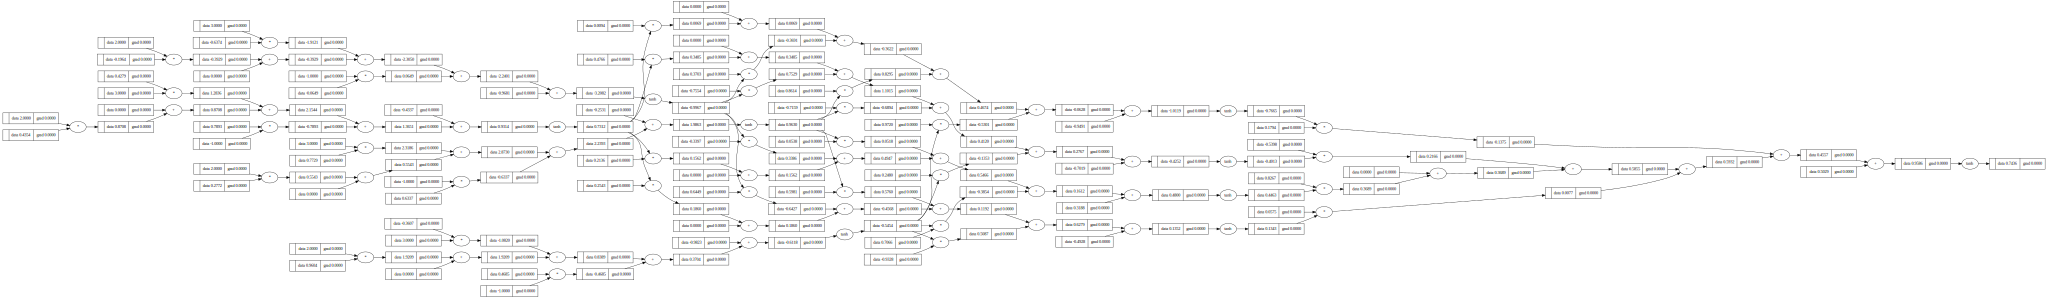

In [ ]:
draw_dot(n(x))

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.7436352864052901),
 Value(data=0.7530865200093536),
 Value(data=0.7525073702583363),
 Value(data=0.5391809942693989)]

In [ ]:
[(ypre-yg)**2 for ypre, yg in zip(ypred, ys)]

[Value(data=0.06572286637649764),
 Value(data=3.0733123466385055),
 Value(data=3.0712820828097893),
 Value(data=0.21235415604253977)]

In [ ]:
[(ypre-yg) for ypre, yg in zip(ypred, ys)]

[Value(data=-0.2563647135947099),
 Value(data=1.7530865200093535),
 Value(data=1.7525073702583363),
 Value(data=-0.4608190057306011)]

In [ ]:
loss = sum([(ypre-yg)**2 for ypre, yg in zip(ypred, ys)])
loss

Value(data=6.422671451867332)

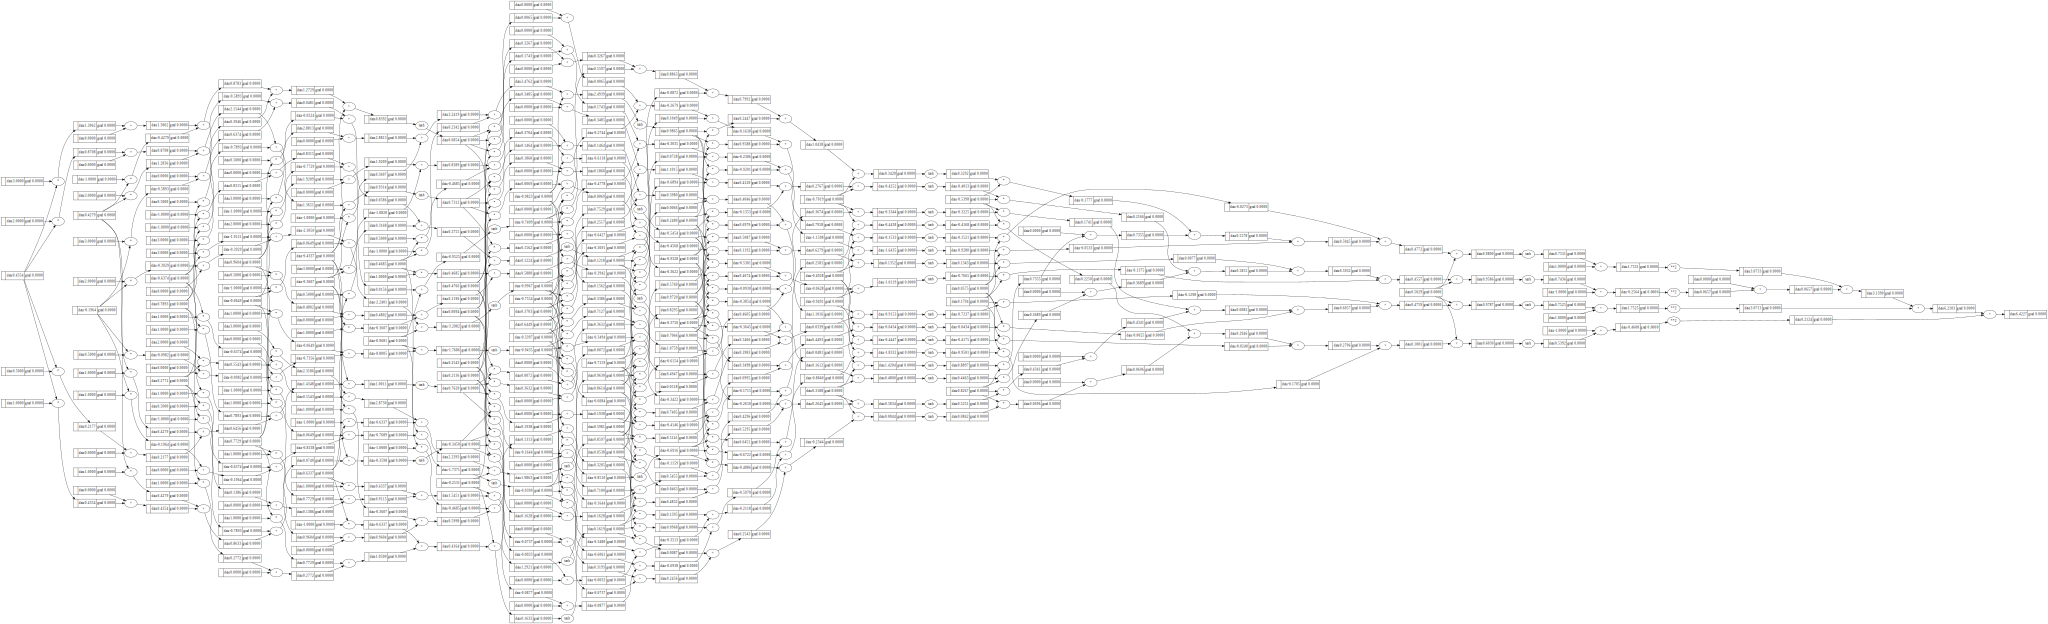

In [ ]:
draw_dot(loss)

In [ ]:
loss.backward()

In [ ]:
n.layers[0].neurons[0].w[2].grad

-0.6618626184979355

In [ ]:
n.layers[0].neurons[0].w[0].data

0.43538421411807726

In [ ]:
# draw_dot(loss)

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=0.48188619040043973)

In [ ]:
len(n.parameters())

41

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.48188619040043973),
 Value(data=-0.07006936450827901),
 Value(data=0.18211508948609337),
 Value(data=-0.2240840932130424)]

In [ ]:
# loss

In [ ]:
loss = sum([(ypre-yg)**2 for ypre, yg in zip(ypred, ys)])
loss

Value(data=4.028990858571716)

In [ ]:
loss.backward()

In [ ]:
n.layers[0].neurons[0].w[2].grad

0.043930445772234594

In [ ]:
n.layers[0].neurons[0].w[2].data

-0.19231209105931968

In [ ]:
# n.layers[0].neurons[0](xs[0])._prev

In [ ]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [ ]:
n.layers[0].neurons[0].w[2].data # Value increased slightly going in opposite direction of gradient

-0.192751395517042

In [ ]:
ypred = [n(x) for x in xs]
loss = sum([(ypre-yg)**2 for ypre, yg in zip(ypred, ys)])
loss

Value(data=4.1249928104173135)

In [ ]:
ypred

[Value(data=0.3879779758874709),
 Value(data=-0.11032655970617919),
 Value(data=0.13785642710158896),
 Value(data=-0.29003324505916495)]

In [ ]:
loss.backward()
for p in n.parameters():
  p.data += -0.01 * p.grad

ypred = [n(x) for x in xs]
loss = sum([(ypre-yg)**2 for ypre, yg in zip(ypred, ys)])
loss
## YOUR MISTAKES ARE AFFECTING THE LOSS LANDSCAPE HERE

Value(data=4.603833979607861)

In [ ]:
ypred

[Value(data=0.16375757702527213),
 Value(data=-0.1236231850552308),
 Value(data=0.02907014393406362),
 Value(data=-0.4413573140328546)]

## Important Blocks

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from graphviz import Digraph

def trace(root):
  #BFS
  nodes, edges = set(), set()

  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v)) # --> set of tuples representing heirarchy from child to parent
        build(child)

  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) # LR = left to right

  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    # create a box node/record for each node

    dot.node(name=uid, label= "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')

    if n._op:
      #if current value node resulted from some operation then create its operation node
      dot.node(name = uid + n._op, label = n._op)

      #connect the operation node to the parent node
      dot.edge(uid + n._op, uid)

  # add in all the edges between children and parent via the operation node
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._backward = lambda : None
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():

      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
      # print(f"{self.label} with grad {self.grad}")

    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only support int/float powers"

    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += (other*(self.data**(other-1)))*out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

    out =  Value(t, (self, ), 'tanh')

    def _backward():
        self.grad += (1 - out.data**2) * out.grad
    out._backward = _backward

    return out

  # <__main__.Value at 0x7e8692086020> vs Value(data=2.0) --> pretty print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __radd__(self, other):
    return self+other

  # don't need specific backward pass instructions for these as we are using already defined primitives
  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __rmul__(self, other):
    return self*other

  def __truediv__(self, other):
    return self * other**-1

  def backward(self):

    topo = []
    visited = set()

    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for ele in v._prev:
          build_topo(ele)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    # print(topo)
    for node in reversed(topo):
      node._backward()

In [ ]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [neuron(x) for neuron in self.neurons]
    return outs[0] if len(outs)==1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) # output of one layer fed back to the next layer --> therefore update x
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=-0.9250825979477515)

In [ ]:
# n.parameters()

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.9250825979477515),
 Value(data=-0.9443956531587248),
 Value(data=-0.8864790961400474),
 Value(data=-0.9429320542982492)]

In [ ]:
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.496906815541705)

In [ ]:
# for p in n.parameters():
#   print(p.data, p.grad)

In [ ]:
loss.backward()

In [ ]:
for p in n.parameters():
  p.data += -0.1 * p.grad

In [ ]:
ypred = [n(x) for x in xs]
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.1321282355703115)

In [ ]:
ypred

[Value(data=-0.8649447296968736),
 Value(data=-0.9000087598028178),
 Value(data=-0.817400586372217),
 Value(data=-0.9002022515439735)]

#Training loop

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

  #backward pass
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 6.780076969948144
1 5.173002569309816
2 1.3034154511723333
3 1.0275596717365103
4 0.06387060468230421
5 0.005349345722606305
6 0.001299086728107279
7 0.002431468922656687
8 0.022152707170033068
9 0.2019128003023166
10 0.00032347919946865557
11 4.546268484568918e-06
12 7.903726660025062e-07
13 1.7603774907395402e-07
14 4.644703854146347e-08
15 1.6557360113020085e-08
16 6.7227980578741905e-09
17 5.338039847274367e-09
18 1.2004409621231732e-08
19 3.960725660536876e-08


In [ ]:
ypred

[Value(data=0.9999972984823622),
 Value(data=-0.9998233732421948),
 Value(data=-0.9999083412354764),
 Value(data=0.9999987281033559)]

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

  #zero_grad before backward pass
  for p in n.parameters():
    p.grad = 0.0

  #backward pass
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 4.431004314426283
1 2.772987008029703
2 2.7193429039999026
3 2.6753069599550043
4 2.628835898444465
5 2.571350621954642
6 2.4889282256276837
7 2.351514175108883
8 2.0877889397009906
9 1.5800543716735174
10 0.9616904285201577
11 0.5769481062311559
12 0.3951821462163375
13 0.29828009220742613
14 0.23990574365737233
15 0.20073756097727216
16 0.1726126822807998
17 0.15142199456496624
18 0.13487006268318172
19 0.12157595203526275


In [ ]:
ypred

[Value(data=0.8220483865310144),
 Value(data=-0.8568921392839247),
 Value(data=-0.8072235725692419),
 Value(data=0.8203710365020452)]

In [ ]:
for k in range(50):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

  #zero_grad before backward pass
  for p in n.parameters():
    p.grad = 0.0

  #backward pass
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.5 * p.grad

  print(k, loss.data)

0 0.11065912592245296
1 0.04670495643363398
2 0.03201271198287322
3 0.024575376404411042
4 0.020002644690120086
5 0.01688596270534233
6 0.014618086420405671
7 0.01289074590511967
8 0.011529814673427776
9 0.010429143220426243
10 0.009520187906415251
11 0.008756644334333218
12 0.008106070830953802
13 0.0075450441242753685
14 0.0070562193903624905
15 0.006626472972050333
16 0.006245688512761284
17 0.0059059401294580495
18 0.005600928659668023
19 0.005325583834116959
20 0.005075777968336175
21 0.0048481162721727665
22 0.004639780842112945
23 0.0044484129360506065
24 0.00427202298677049
25 0.0041089210074892035
26 0.0039576621879681174
27 0.0038170039443224195
28 0.0036858717016469288
29 0.0035633314037429166
30 0.003448567254465103
31 0.003340863563795428
32 0.0032395898411122287
33 0.0031441884770950887
34 0.0030541645041666007
35 0.0029690770371863105
36 0.0028885320810697925
37 0.002812176457091889
38 0.0027396926498849438
39 0.0026707944162263713
40 0.0026052230273169268
41 0.002542744